In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix,RocCurveDisplay, classification_report
from sklearn.pipeline import Pipeline

In [2]:
# Import our data and assign it to data
data = pd.read_csv("datafile_full.csv", index_col=0)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
identity = data.loc[data.index[0:],data.columns[0]].keys()

In [3]:
#DATA CLEANING STEP - UNDERSTANDING DATA
data_new = data.drop(columns=['var_45'])

In [4]:
df = data_new.fillna(data_new.median())

In [5]:
# DATA PATRITIONING
random_seed = 100
X = df.drop('target', axis =1)
y = df['target']
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42)

# Step 2: Validation = 10% of full dataset
# 10k is 1/7th of 70k → test_size = 0.142857
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.142857,
    stratify=y_temp,
    random_state=42)

print("TRAIN:", X_train.shape)
print("VALIDATION:", X_val.shape)
print("TEST:", X_test.shape)

TRAIN: (60000, 199)
VALIDATION: (10000, 199)
TEST: (30000, 199)


In [8]:
# Training set: ORIGINAL
X_train_0 = X_train.copy()
y_train_0 = y_train.copy()
print("--- Training set 0: Keeping the original ---")
print(y_train_0.value_counts())


--- Training set 0: Keeping the original ---
target
0    53977
1     6023
Name: count, dtype: int64



=== Balanced Random Forest: top_180 (180 features) ===
AUC: 0.8410

Confusion Matrix:
[[19900  7089]
 [  639  2372]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     26989
           1       0.25      0.79      0.38      3011

    accuracy                           0.74     30000
   macro avg       0.61      0.76      0.61     30000
weighted avg       0.90      0.74      0.79     30000


=== Balanced Random Forest: top_120 (120 features) ===
AUC: 0.8383

Confusion Matrix:
[[19860  7129]
 [  664  2347]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     26989
           1       0.25      0.78      0.38      3011

    accuracy                           0.74     30000
   macro avg       0.61      0.76      0.61     30000
weighted avg       0.90      0.74      0.79     30000


=== Balanced Random Forest: top_60 (60 features) ===
AUC: 0.8

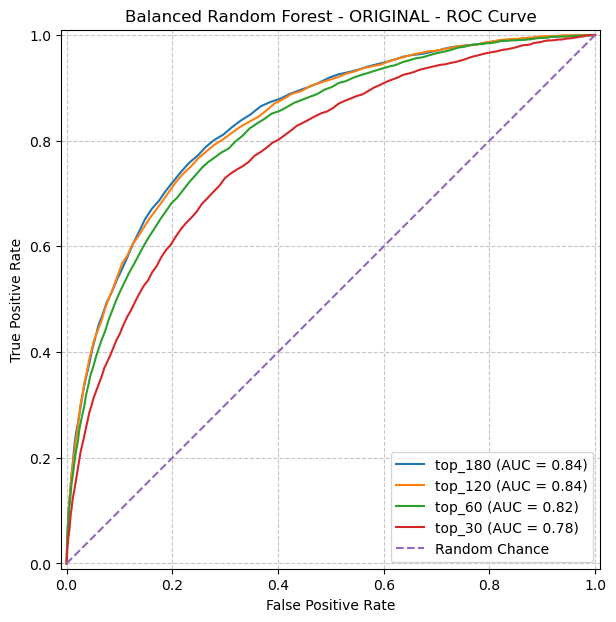

In [9]:
#ORIGINAL
# Fit a Random Forest (weighted) to rank features
RF_0 = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    class_weight='balanced',
    random_state=random_seed
)
RF_0.fit(X_train_0, y_train_0)
# Get the features
feature_importance_rf = (pd.DataFrame({
        'feature': X_train_0.columns,
        'importance': RF_0.feature_importances_})
    .sort_values('importance', ascending=False))
k_list=[180,120,60,30]
feature_sets = {f"top_{k}": feature_importance_rf['feature'].iloc[:k].tolist() for k in k_list}
# Training model
fig, ax = plt.subplots(figsize=(7, 7))
for name, feats in feature_sets.items():
    print(f" Balanced Random Forest: {name} ({len(feats)} features) ===")

    X_train_sub_0 = X_train_0[feats]
    X_test_sub_0  = X_test[feats]

    BRF = BalancedRandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        sampling_strategy='auto',
        replacement=False,
        random_state=random_seed)

    BRF.fit(X_train_sub_0, y_train_0)

    y_pred_0 = BRF.predict(X_test_sub_0)
    y_prob_0 = BRF.predict_proba(X_test_sub_0)[:, 1]

    auc = roc_auc_score(y_test, y_prob_0)
    print(f"AUC: {auc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_0))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_0, zero_division=0))

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob_0,
        name=f"{name}",
        ax=ax)
#Plotting
ax.plot([0, 1], [0, 1], "--", label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Balanced Random Forest - ORIGINAL - ROC Curve")
ax.grid(True, linestyle="--", alpha=0.7)
ax.legend()
plt.show()


In [10]:
#Training set 1: SMOTE to 0.43 (30:70 ratio) & then RUS to 0.67 (40:60 ratio)
target_final_1 = 0.18
rus_1 = RandomUnderSampler(sampling_strategy=target_final_1, random_state=random_seed)
X_train_1, y_train_1 = rus_1.fit_resample(X_train,y_train)
print("--- Before Undersampling ---")
print(y_train.value_counts())
print("--- After Undersampling ---")
print(y_train_1.value_counts())

--- Before Undersampling ---
target
0    53977
1     6023
Name: count, dtype: int64
--- After Undersampling ---
target
0    33461
1     6023
Name: count, dtype: int64



=== Balanced Random Forest: top_180 (180 features) ===
AUC: 0.7819

Confusion Matrix:
[[19840  7149]
 [  676  2335]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     26989
           1       0.25      0.78      0.37      3011

    accuracy                           0.74     30000
   macro avg       0.61      0.76      0.60     30000
weighted avg       0.89      0.74      0.79     30000


=== Balanced Random Forest: top_120 (120 features) ===
AUC: 0.7819

Confusion Matrix:
[[19913  7076]
 [  677  2334]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     26989
           1       0.25      0.78      0.38      3011

    accuracy                           0.74     30000
   macro avg       0.61      0.76      0.61     30000
weighted avg       0.89      0.74      0.79     30000


=== Balanced Random Forest: top_60 (60 features) ===
AUC: 0.7

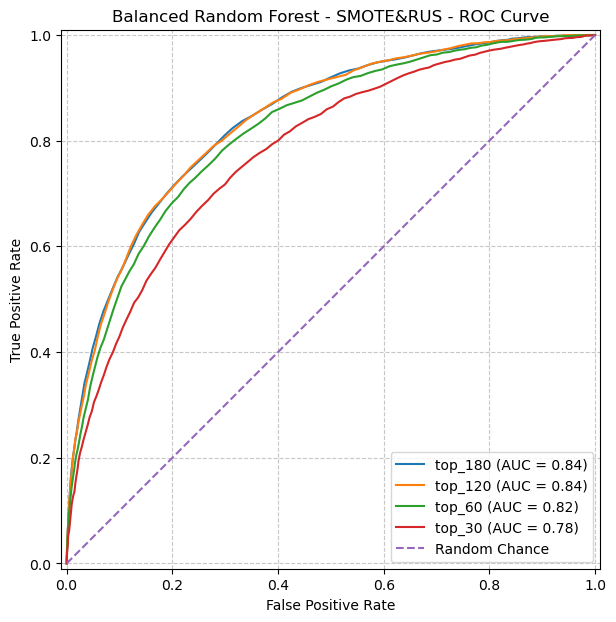

In [11]:
# SMOTE & RUS - BALANCED RANDOM FOREST
# Fit a Random Forest (weighted) to rank features
RF_1 = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    class_weight='balanced',
    random_state=random_seed
)
RF_1.fit(X_train_1, y_train_1)
# Get features
feature_importance_rf = (pd.DataFrame({
        'feature': X_train_1.columns,
        'importance': RF_1.feature_importances_})
    .sort_values('importance', ascending=False))
k_list=[180,120,60,30]
feature_sets_1 = {f"top_{k}": feature_importance_rf['feature'].iloc[:k].tolist() for k in k_list}

fig, ax = plt.subplots(figsize=(7, 7))
for name, feats in feature_sets.items():
    print(f" Balanced Random Forest: {name} ({len(feats)} features) ===")

    X_train_sub_1 = X_train_1[feats]
    X_test_sub_1  = X_test[feats]

    BRF_1 = BalancedRandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        sampling_strategy='auto',
        replacement=False,
        random_state=random_seed)

    BRF_1.fit(X_train_sub_1, y_train_1)

    y_pred_1 = BRF_1.predict(X_test_sub_1)
    y_prob_1 = BRF_1.predict_proba(X_test_sub_1)[:, 1]

    auc_1 = roc_auc_score(y_test, y_prob_1)
    print(f"AUC: {auc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_1))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_1, zero_division=0))

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob_1,
        name=f"{name}",
        ax=ax)
# === ROC formatting ===
ax.plot([0, 1], [0, 1], "--", label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Balanced Random Forest - SMOTE&RUS - ROC Curve")
ax.grid(True, linestyle="--", alpha=0.7)
ax.legend()
plt.show()


In [12]:
#Training set 2: RUS to minority/majority ratio = 0.18 (15:85 ratio)
target_final_2 = 0.43
rus_2 = RandomUnderSampler(sampling_strategy=target_final_2, random_state=random_seed)
X_train_2, y_train_2 = rus_2.fit_resample(X_train,y_train)
print("--- Before Undersampling ---")
print(y_train.value_counts())
print("--- After Undersampling ---")
print(y_train_2.value_counts())

--- Before Undersampling ---
target
0    53977
1     6023
Name: count, dtype: int64
--- After Undersampling ---
target
0    14006
1     6023
Name: count, dtype: int64



=== Balanced Random Forest: top_180 (180 features) ===
AUC: 0.7819

Confusion Matrix:
[[19829  7160]
 [  667  2344]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.84     26989
           1       0.25      0.78      0.37      3011

    accuracy                           0.74     30000
   macro avg       0.61      0.76      0.60     30000
weighted avg       0.90      0.74      0.79     30000


=== Balanced Random Forest: top_120 (120 features) ===
AUC: 0.7819

Confusion Matrix:
[[19800  7189]
 [  662  2349]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.83     26989
           1       0.25      0.78      0.37      3011

    accuracy                           0.74     30000
   macro avg       0.61      0.76      0.60     30000
weighted avg       0.90      0.74      0.79     30000


=== Balanced Random Forest: top_60 (60 features) ===
AUC: 0.7

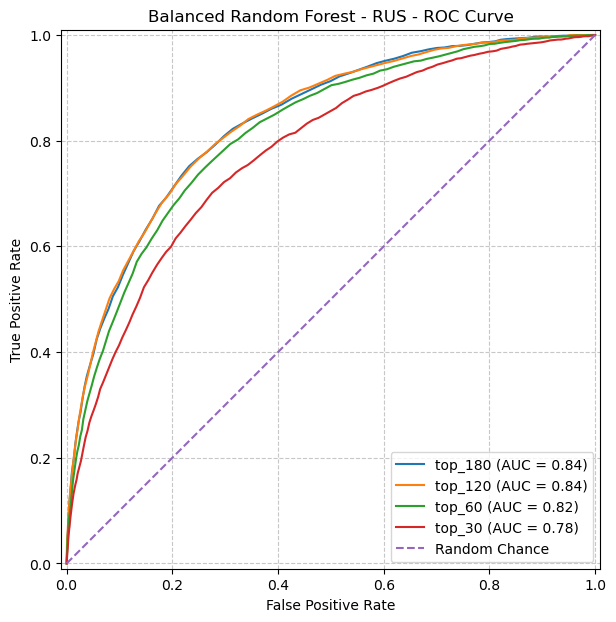

In [13]:
# RUS - BALANCED RANDOM FOREST
# Fit a Random Forest (weighted) to rank features
RF_2 = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    class_weight='balanced',
    random_state=random_seed
)
RF_2.fit(X_train_2, y_train_2)
# Get features
feature_importance_rf = (pd.DataFrame({
        'feature': X_train_2.columns,
        'importance': RF_2.feature_importances_})
    .sort_values('importance', ascending=False))

feature_sets_2 = {f"top_{k}": feature_importance_rf['feature'].iloc[:k].tolist() for k in k_list}

fig, ax = plt.subplots(figsize=(7, 7))
for name, feats in feature_sets.items():
    print(f"\n=== Balanced Random Forest: {name} ({len(feats)} features) ===")

    X_train_sub_2 = X_train_2[feats]
    X_test_sub_2  = X_test[feats]

    BRF_2 = BalancedRandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        sampling_strategy='auto',
        replacement=False,
        random_state=random_seed)

    BRF_2.fit(X_train_sub_2, y_train_2)

    y_pred_2 = BRF_2.predict(X_test_sub_2)
    y_prob_2 = BRF_2.predict_proba(X_test_sub_2)[:, 1]

    auc_2 = roc_auc_score(y_test, y_prob_2)
    print(f"AUC: {auc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_2))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_2, zero_division=0))

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob_2,
        name=f"{name}",
        ax=ax)
# === ROC formatting====
ax.plot([0, 1], [0, 1], "--", label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Balanced Random Forest - RUS - ROC Curve")
ax.grid(True, linestyle="--", alpha=0.7)
ax.legend()
plt.show()

In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support)
from scipy.stats import randint



In [16]:
data = pd.read_csv("datafile_full.csv")

In [17]:
data = data.drop(columns=['var_45'], errors='ignore')

In [18]:
data = data.fillna(data.median(numeric_only=True))

In [19]:
# Separate features & target
X = data.drop(columns=['target', 'ID_code'])
y = data['target'].astype(int)


In [20]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42)

In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.30,  # 0.25 of 0.8 = 0.2 overall -> 60/20/20
    stratify=y_temp,
    random_state=42)

In [22]:
print("Train size:", X_train.shape, "Pos rate:", y_train.mean())
print("Val size  :", X_val.shape,   "Pos rate:", y_val.mean())
print("Test size :", X_test.shape,  "Pos rate:", y_test.mean())

Train size: (49000, 199) Pos rate: 0.10038775510204082
Val size  : (21000, 199) Pos rate: 0.10038095238095238
Test size : (30000, 199) Pos rate: 0.10036666666666667


In [28]:
rf_base = RandomForestClassifier(
    n_jobs=-1,
    random_state=42)

In [31]:
param_dist = {
    "n_estimators": randint(100, 251),             # 300–800 trees → more stable with slightly less training data
    "max_depth": [10, 15, 20, 25],            # deeper search space
    "min_samples_split": randint(2, 20),           # allow more variety
    "min_samples_leaf": randint(1, 10),            # more robust leaf sizes
    "max_features": ["sqrt", "log2", None],        # let model choose optimal split size
    "bootstrap": [True],                           # standard
    "class_weight": ["balanced", "balanced_subsample"]  # MUST keep for imbalance
}

In [35]:
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=5,              # increase if you have more time
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42) 

In [36]:
rf_search.fit(X_train, y_train)

print("\nBEST PARAMETER SET FOUND:")
print(rf_search.best_params_)

print("\nBEST CROSS-VALIDATION AUC (TRAINING DATA):")
print(rf_search.best_score_)


Fitting 3 folds for each of 5 candidates, totalling 15 fits

BEST PARAMETER SET FOUND:
{'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 221}

BEST CROSS-VALIDATION AUC (TRAINING DATA):
0.8325297987519308


In [37]:
# Best model from the search
best_rf = rf_search.best_estimator_

In [38]:
y_val_proba = best_rf.predict_proba(X_val)[:, 1]
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

auc_val = roc_auc_score(y_val, y_val_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

print("\nValidation AUC (threshold 0.5):", auc_val)
print("Test AUC (threshold 0.5):", auc_test)

print("\nClassification report on TEST (threshold 0.5):")
print(classification_report(y_test, (y_test_proba >= 0.5).astype(int)))


Validation AUC (threshold 0.5): 0.8343957322979597
Test AUC (threshold 0.5): 0.8374036513811997

Classification report on TEST (threshold 0.5):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     26989
           1       1.00      0.00      0.00      3011

    accuracy                           0.90     30000
   macro avg       0.95      0.50      0.47     30000
weighted avg       0.91      0.90      0.85     30000



In [39]:
def find_best_threshold(y_true, y_proba, beta=1.0):
    """
    Search for the threshold which maximises F-beta score on the validation set.
    beta = 1.0 -> F1 (precision and recall weighted equally)
    beta < 1 -> favour precision
    beta > 1 -> favour recall
    """
    thresholds = np.linspace(0.05, 0.95, 19)  # 0.05, 0.10, ..., 0.95
    best_thr = 0.5
    best_score = -1

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, average='binary', zero_division=0
        )
        # General F-beta formula
        if p + r == 0:
            f_beta = 0
        else:
            f_beta = (1 + beta**2) * (p * r) / (beta**2 * p + r)
        if f_beta > best_score:
            best_score = f_beta
            best_thr = thr

    return best_thr, best_score

In [40]:
best_thr, best_f1 = find_best_threshold(y_val, y_val_proba, beta=1.0)
print("\nBest threshold on validation (by F1):", best_thr)
print("Best validation F1 at this threshold:", best_f1)

# Apply tuned threshold on TEST set
y_test_pred_tuned = (y_test_proba >= best_thr).astype(int)

print("\n=== TEST PERFORMANCE WITH TUNED THRESHOLD ===")
print("Test AUC:", auc_test)  # AUC independent of threshold

print("\nClassification report (tuned threshold):")
print(classification_report(y_test, y_test_pred_tuned))

print("Confusion matrix (tuned threshold):")
print(confusion_matrix(y_test, y_test_pred_tuned))


Best threshold on validation (by F1): 0.3
Best validation F1 at this threshold: 0.41873128233052004

=== TEST PERFORMANCE WITH TUNED THRESHOLD ===
Test AUC: 0.8374036513811997

Classification report (tuned threshold):
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     26989
           1       0.50      0.37      0.43      3011

    accuracy                           0.90     30000
   macro avg       0.72      0.66      0.69     30000
weighted avg       0.89      0.90      0.89     30000

Confusion matrix (tuned threshold):
[[25885  1104]
 [ 1897  1114]]


In [41]:
#another version testing 

In [42]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np


# 1. BALANCED RANDOM FOREST MODEL  

brf = BalancedRandomForestClassifier(
    n_estimators=300,         
    max_depth=None,           
    sampling_strategy='auto', 
    random_state=42)

brf.fit(X_train, y_train)

# Probabilities
val_proba = brf.predict_proba(X_val)[:, 1]
test_proba = brf.predict_proba(X_test)[:, 1]

# AUC scores
print("Validation AUC:", roc_auc_score(y_val, val_proba))
print("Test AUC:", roc_auc_score(y_test, test_proba))


# 2. THRESHOLD TUNING (TO MAXIMISE RECALL OR F1)

thresholds = np.linspace(0.05, 0.50, 10)
best_f1, best_t = 0, 0.5

for t in thresholds:
    preds = (val_proba >= t).astype(int)
    report = classification_report(y_val, preds, output_dict=True, zero_division=0)
    f1 = report['1']['f1-score']
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("\nBest Threshold:", best_t)
print("Best Validation F1:", best_f1)


# 3. FINAL TEST PERFORMANCE

final_preds = (test_proba >= best_t).astype(int)

print("\n=== FINAL BALANCED RF PERFORMANCE ===")
print("Test AUC:", roc_auc_score(y_test, test_proba))
print(classification_report(y_test, final_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_preds))

Validation AUC: 0.8407089951229821
Test AUC: 0.8396374051994244

Best Threshold: 0.5
Best Validation F1: 0.3543161779782653

=== FINAL BALANCED RF PERFORMANCE ===
Test AUC: 0.8396374051994244
              precision    recall  f1-score   support

           0       0.97      0.68      0.80     26989
           1       0.22      0.83      0.35      3011

    accuracy                           0.69     30000
   macro avg       0.60      0.75      0.58     30000
weighted avg       0.90      0.69      0.75     30000

Confusion Matrix:
 [[18287  8702]
 [  515  2496]]
